# Task2 Readout Chain Notebook

This notebook uses the following 4 config files directly:

- `required_tasks/task2_readout_io.yaml`
- `templates/solvers/qutip.yaml`
- `templates/devices/single_qubit.yaml`
- `templates/pulses/single_qubit.yaml`

The goal here is not a final-state `p1` proxy. Instead, we take the lowered `RO_0` waveform from the workflow and feed it into a minimal readout chain model:

`readout pulse -> cavity output -> IQ integration -> nearest-centroid discrimination -> readout error`

The current workflow already lowers `measure` into an `RO_0` pulse, but it does not yet include a built-in IQ discrimination chain. So this notebook reuses workflow pulse generation and adds a notebook-side dispersive readout model.

The scanned physical parameter is `measure_duration_ns`:

- longer readout time usually improves IQ separation and lowers assignment error
- longer readout time also increases the `T1/Tup` exposure window and raises bit error


In [5]:
from __future__ import annotations

import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from qsim.workflow.contracts import compose_workflow_task
from qsim.workflow.stages import parse_compile_lower_model
from qsim.workflow.task_io import (
    load_device_config_file,
    load_pulse_config_file,
    load_solver_config_file,
    load_task_config_file,
)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'qsim').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing src/qsim')


ROOT = find_repo_root()
NOTEBOOK_DIR = ROOT / 'examples' / 'noise_simulation_tests'
TASK_PATH = NOTEBOOK_DIR / 'required_tasks' / 'task2_readout_io.yaml'

task_base = load_task_config_file(TASK_PATH)
solver_base = load_solver_config_file(task_base.input.solver_config_path)
device_base = load_device_config_file(task_base.input.device_config_path)
pulse_base = load_pulse_config_file(task_base.input.pulse_config_path)

SAMPLE_RATE_HZ = 1.0e9
IQ_SHOTS = 3000
IQ_PLOT_SHOTS = 400
RNG_SEED = 12345
MEASURE_DURATION_SWEEP_NS = [80.0, 120.0, 180.0, 260.0, 360.0, 500.0, 700.0]
READOUT_CHAIN_DEFAULTS = {
    'kappa_Hz': 8.0e6,
    'kappa_ext_Hz': 6.0e6,
    'drive_scale_Hz': 3.5e7,
    'line_noise_sigma': 4.0e4,
}

plt.style.use('seaborn-v0_8-whitegrid')

display(
    pd.DataFrame(
        [
            {'config': 'task', 'path': str(TASK_PATH)},
            {'config': 'solver', 'path': str(task_base.input.solver_config_path)},
            {'config': 'device', 'path': str(task_base.input.device_config_path)},
            {'config': 'pulse', 'path': str(task_base.input.pulse_config_path)},
        ]
    )
)


,config,path
0,task,D:\超导量子计算机噪声抑制\qsim\examples\noise_simulation_...
1,solver,D:\超导量子计算机噪声抑制\qsim\templates\solvers\qutip.json
2,device,D:\超导量子计算机噪声抑制\qsim\templates\devices\single_q...
3,pulse,D:\超导量子计算机噪声抑制\qsim\templates\pulses\single_qu...


## Physical Model

We use a single-mode cavity plus a single qubit in the dispersive-readout approximation. For a fixed qubit eigenstate `|g>` or `|e>`, the cavity amplitude satisfies

\[
\dot\alpha_{g/e}(t)= -\left(\frac{\kappa}{2}+i(\Delta_r \mp \chi)\right)\alpha_{g/e}(t)-i\varepsilon(t)
\]

where:

- `\kappa` is the cavity linewidth
- `\chi` is the dispersive shift
- `\Delta_r = \omega_r - \omega_d`
- `\varepsilon(t)` comes from the lowered `RO_0` envelope

The output field is modeled as

\[
s_{g/e}(t)=\sqrt{\kappa_{ext}}\,\alpha_{g/e}(t)+\xi(t)
\]

with complex Gaussian readout-line noise `\xi(t)`. After matched filtering and time integration, we get one complex IQ point

\[
z = \int_0^T w^*(t)s(t)\,dt = I+iQ
\]

Then we use nearest-centroid discrimination to obtain `assignment_error_rate`.
In parallel, we estimate the real qubit bit-flip probability during the readout window from `T1/Tup`:

\[
P_{bit}=\frac12\left[(1-e^{-T_{ro}/T_1})+(1-e^{-T_{ro}/T_{up}})\right]
\]

So task2 reports three related error metrics:

- `assignment_error_rate`: discrimination error from the readout chain itself
- `bit_error_rate`: real qubit flips during the readout window
- `total_error_rate`: an approximate combined error assuming the two channels are independent


In [6]:
def _first_or_scalar(value, default: float = 0.0) -> float:
    if isinstance(value, (list, tuple)):
        if not value:
            return float(default)
        return float(value[0])
    if value is None:
        return float(default)
    return float(value)


def trim_active_window(times_s: np.ndarray, values: np.ndarray, *, threshold: float = 1.0e-12) -> tuple[np.ndarray, np.ndarray]:
    mask = np.abs(values) > threshold
    if not np.any(mask):
        raise ValueError('RO_0 waveform is empty after lowering.')
    start = int(np.argmax(mask))
    stop = int(len(mask) - np.argmax(mask[::-1]))
    active_t = np.asarray(times_s[start:stop], dtype=float)
    active_y = np.asarray(values[start:stop], dtype=float)
    active_t = active_t - active_t[0]
    return active_t, active_y


def compile_readout_pulse(*, measure_duration_ns: float) -> dict:
    task_cfg = copy.deepcopy(task_base)
    solver_cfg = copy.deepcopy(solver_base)
    device_cfg = copy.deepcopy(device_base)
    pulse_cfg = copy.deepcopy(pulse_base)

    pulse_cfg['measure_duration_ns'] = float(measure_duration_ns)
    device_cfg.pulse = {**dict(device_cfg.pulse or {}), **pulse_cfg}
    workflow_task = compose_workflow_task(task_cfg, solver_cfg, device_cfg)

    parsed = parse_compile_lower_model(
        qasm_text=workflow_task.input.qasm_text,
        backend_path=None,
        backend_config=workflow_task.input.backend_config,
        out=NOTEBOOK_DIR / 'runs' / 'notebooks' / 'task2_readout_io' / 'pulse_probe',
        device=workflow_task.input.device,
        pulse=workflow_task.input.pulse,
        frame=workflow_task.input.frame,
        schedule_policy=workflow_task.input.schedule_policy,
        reset_feedback_policy=workflow_task.input.reset_feedback_policy,
        noise=workflow_task.input.noise,
        solver_run={
            'dt_s': solver_base.run.dt_s,
            't_end_s': solver_base.run.t_end_s,
            't_padding_s': solver_base.run.t_padding_s,
        },
        solver_mode=solver_base.run.solver_mode,
        param_bindings=workflow_task.input.param_bindings,
        persist_artifacts=False,
    )

    ro_payload = parsed['pulse_samples']['RO_0']
    active_t_s, active_env = trim_active_window(ro_payload['t'], ro_payload['y'])
    return {
        't_s': active_t_s,
        'envelope': active_env,
        'dt_s': float(np.mean(np.diff(active_t_s))),
        'carrier_freq_Hz': float(ro_payload['carrier_freq_Hz'][0]),
        'pulse_ir': parsed['pulse_ir'],
    }


def derive_readout_parameters(device_cfg, pulse_cfg) -> dict[str, float]:
    device = dict(device_cfg.device or {})
    noise = dict(device_cfg.noise or {})
    qubit = dict((device.get('qubits') or [{}])[0])

    qubit_freq_hz = float(qubit.get('freq_Hz', 5.0e9))
    anh_hz = float(qubit.get('anharmonicity_Hz', -2.0e8))
    cavity_freq_hz = float(device.get('cavity_freq_Hz', pulse_cfg.get('ro_freq_Hz', 6.5e9)))
    g_cavity_hz = _first_or_scalar(device.get('g_cavity_Hz', 0.0), default=0.0)
    delta_hz = qubit_freq_hz - cavity_freq_hz
    denom = delta_hz * (delta_hz + anh_hz)
    chi_hz = 0.0 if abs(denom) < 1.0 else -(g_cavity_hz ** 2) * anh_hz / denom

    return {
        'qubit_freq_Hz': qubit_freq_hz,
        'anharmonicity_Hz': anh_hz,
        'cavity_freq_Hz': cavity_freq_hz,
        'g_cavity_Hz': g_cavity_hz,
        'chi_Hz': float(chi_hz),
        'kappa_Hz': float(READOUT_CHAIN_DEFAULTS['kappa_Hz']),
        'kappa_ext_Hz': float(READOUT_CHAIN_DEFAULTS['kappa_ext_Hz']),
        'drive_scale_Hz': float(READOUT_CHAIN_DEFAULTS['drive_scale_Hz']),
        'line_noise_sigma': float(READOUT_CHAIN_DEFAULTS['line_noise_sigma']),
        'T1_s': float(noise.get('T1_s', np.inf)),
        'Tup_s': float(noise.get('Tup_s', np.inf)),
        'T2_s': float(noise.get('T2_s', np.inf)),
        'ro_freq_Hz': float(pulse_cfg.get('ro_freq_Hz', cavity_freq_hz)),
    }


def cavity_output_trace(t_s: np.ndarray, envelope: np.ndarray, *, qubit_state: str, params: dict[str, float]) -> tuple[np.ndarray, np.ndarray]:
    dt_s = float(np.mean(np.diff(t_s)))
    sign = -1.0 if qubit_state == 'g' else 1.0
    delta_hz = (params['cavity_freq_Hz'] - params['ro_freq_Hz']) + sign * params['chi_Hz']
    delta_rad_s = 2.0 * np.pi * delta_hz
    kappa_rad_s = 2.0 * np.pi * params['kappa_Hz']
    drive_rad_s = 2.0 * np.pi * params['drive_scale_Hz'] * np.asarray(envelope, dtype=float)

    alpha = np.zeros(len(t_s), dtype=np.complex128)
    for idx in range(1, len(t_s)):
        alpha[idx] = alpha[idx - 1] + dt_s * (
            -(0.5 * kappa_rad_s + 1j * delta_rad_s) * alpha[idx - 1] - 1j * drive_rad_s[idx - 1]
        )

    output = np.sqrt(2.0 * np.pi * params['kappa_ext_Hz']) * alpha
    return alpha, output


def matched_filter(mean_g: np.ndarray, mean_e: np.ndarray) -> np.ndarray:
    delta = np.asarray(mean_e - mean_g, dtype=np.complex128)
    norm = float(np.sqrt(np.vdot(delta, delta).real))
    if norm <= 0.0:
        raise ValueError('Matched filter received identical g/e templates.')
    return np.conjugate(delta) / norm


def integrate_iq(trace: np.ndarray, weight: np.ndarray, dt_s: float) -> np.ndarray:
    return dt_s * np.sum(np.asarray(trace) * np.asarray(weight), axis=-1)


def draw_iq_samples(mean_trace: np.ndarray, *, weight: np.ndarray, dt_s: float, noise_sigma: float, shots: int, rng) -> np.ndarray:
    noise = noise_sigma * (
        rng.normal(size=(shots, mean_trace.size)) + 1j * rng.normal(size=(shots, mean_trace.size))
    ) / np.sqrt(2.0)
    traces = mean_trace[None, :] + noise
    return integrate_iq(traces, weight, dt_s)


def bit_flip_metrics(*, measure_duration_ns: float, params: dict[str, float]) -> dict[str, float]:
    t_ro_s = float(measure_duration_ns) * 1.0e-9

    def transition_probability(time_constant_s: float) -> float:
        if not np.isfinite(time_constant_s) or time_constant_s <= 0.0:
            return 0.0
        return float(1.0 - np.exp(-t_ro_s / time_constant_s))

    p_g_to_e = transition_probability(params['Tup_s'])
    p_e_to_g = transition_probability(params['T1_s'])
    bit_error_rate = 0.5 * (p_g_to_e + p_e_to_g)
    return {
        'p_g_to_e': p_g_to_e,
        'p_e_to_g': p_e_to_g,
        'bit_error_rate': float(bit_error_rate),
    }


def evaluate_readout_chain(*, measure_duration_ns: float, shots: int = IQ_SHOTS, seed: int = RNG_SEED) -> dict:
    pulse_payload = compile_readout_pulse(measure_duration_ns=measure_duration_ns)
    params = derive_readout_parameters(device_base, pulse_base)
    params['ro_freq_Hz'] = pulse_payload['carrier_freq_Hz']

    t_s = pulse_payload['t_s']
    envelope = pulse_payload['envelope']
    dt_s = pulse_payload['dt_s']

    alpha_g, output_g = cavity_output_trace(t_s, envelope, qubit_state='g', params=params)
    alpha_e, output_e = cavity_output_trace(t_s, envelope, qubit_state='e', params=params)

    weight = matched_filter(output_g, output_e)
    centroid_g = integrate_iq(output_g, weight, dt_s)
    centroid_e = integrate_iq(output_e, weight, dt_s)

    rng = np.random.default_rng(seed)
    z_g = draw_iq_samples(output_g, weight=weight, dt_s=dt_s, noise_sigma=params['line_noise_sigma'], shots=shots, rng=rng)
    z_e = draw_iq_samples(output_e, weight=weight, dt_s=dt_s, noise_sigma=params['line_noise_sigma'], shots=shots, rng=rng)

    p_err_g = float(np.mean(np.abs(z_g - centroid_e) < np.abs(z_g - centroid_g)))
    p_err_e = float(np.mean(np.abs(z_e - centroid_g) < np.abs(z_e - centroid_e)))
    assignment_error_rate = 0.5 * (p_err_g + p_err_e)

    bit_metrics = bit_flip_metrics(measure_duration_ns=measure_duration_ns, params=params)
    total_error_rate = 1.0 - (1.0 - assignment_error_rate) * (1.0 - bit_metrics['bit_error_rate'])

    return {
        'measure_duration_ns': float(measure_duration_ns),
        'params': params,
        't_s': t_s,
        'envelope': envelope,
        'alpha_g': alpha_g,
        'alpha_e': alpha_e,
        'output_g': output_g,
        'output_e': output_e,
        'centroid_g': centroid_g,
        'centroid_e': centroid_e,
        'z_g': z_g,
        'z_e': z_e,
        'assignment_error_rate': float(assignment_error_rate),
        'bit_error_rate': float(bit_metrics['bit_error_rate']),
        'p_g_to_e': float(bit_metrics['p_g_to_e']),
        'p_e_to_g': float(bit_metrics['p_e_to_g']),
        'total_error_rate': float(total_error_rate),
        'centroid_separation': float(np.abs(centroid_e - centroid_g)),
        'mean_nbar_g': float(np.mean(np.abs(alpha_g) ** 2)),
        'mean_nbar_e': float(np.mean(np.abs(alpha_e) ** 2)),
    }


In [7]:
base_params = derive_readout_parameters(device_base, pulse_base)
summary_df = pd.DataFrame(
    [
        {'parameter': 'qubit_freq_GHz', 'value': base_params['qubit_freq_Hz'] / 1.0e9},
        {'parameter': 'cavity_freq_GHz', 'value': base_params['cavity_freq_Hz'] / 1.0e9},
        {'parameter': 'anharmonicity_MHz', 'value': base_params['anharmonicity_Hz'] / 1.0e6},
        {'parameter': 'g_cavity_MHz', 'value': base_params['g_cavity_Hz'] / 1.0e6},
        {'parameter': 'chi_kHz', 'value': base_params['chi_Hz'] / 1.0e3},
        {'parameter': 'kappa_MHz', 'value': base_params['kappa_Hz'] / 1.0e6},
        {'parameter': 'kappa_ext_MHz', 'value': base_params['kappa_ext_Hz'] / 1.0e6},
        {'parameter': 'drive_scale_MHz', 'value': base_params['drive_scale_Hz'] / 1.0e6},
        {'parameter': 'line_noise_sigma', 'value': base_params['line_noise_sigma']},
        {'parameter': 'T1_us', 'value': base_params['T1_s'] / 1.0e-6},
        {'parameter': 'Tup_us', 'value': base_params['Tup_s'] / 1.0e-6},
    ]
)
summary_df


,parameter,value
0,qubit_freq_GHz,5.000000
1,cavity_freq_GHz,6.500000
2,anharmonicity_MHz,-200.000000
3,g_cavity_MHz,70.000000
4,chi_kHz,384.313725
5,kappa_MHz,8.000000
6,kappa_ext_MHz,6.000000
7,drive_scale_MHz,35.000000
8,line_noise_sigma,40000.000000
9,T1_us,30.000000


In [8]:
rows = []
results_by_duration = {}

for idx, measure_duration_ns in enumerate(MEASURE_DURATION_SWEEP_NS):
    result = evaluate_readout_chain(
        measure_duration_ns=measure_duration_ns,
        shots=IQ_SHOTS,
        seed=RNG_SEED + idx,
    )
    results_by_duration[measure_duration_ns] = result
    rows.append(
        {
            'measure_duration_ns': result['measure_duration_ns'],
            'assignment_error_rate': result['assignment_error_rate'],
            'bit_error_rate': result['bit_error_rate'],
            'total_error_rate': result['total_error_rate'],
            'p_g_to_e': result['p_g_to_e'],
            'p_e_to_g': result['p_e_to_g'],
            'centroid_separation': result['centroid_separation'],
            'mean_nbar_g': result['mean_nbar_g'],
            'mean_nbar_e': result['mean_nbar_e'],
        }
    )

df = pd.DataFrame(rows)
display(df)
df


,measure_duration_ns,assignment_error_rate,bit_error_rate,total_error_rate,p_g_to_e,p_e_to_g,centroid_separation,mean_nbar_g,mean_nbar_e
0,80.0,0.374667,0.001665,0.375708,0.000666,0.002663,0.000019,12.942020,12.942020
1,120.0,0.243333,0.002496,0.245222,0.001000,0.003992,0.000039,21.497066,21.497066
2,180.0,0.114000,0.003740,0.117314,0.001499,0.005982,0.000067,29.551247,29.551247
3,260.0,0.040833,0.005397,0.046010,0.002164,0.008629,0.000098,35.259844,35.259844
4,360.0,0.010833,0.007462,0.018214,0.002996,0.011928,0.000127,38.948364,38.948364
5,500.0,0.001667,0.010343,0.011993,0.004158,0.016529,0.000160,41.642090,41.642090
6,700.0,0.000167,0.014440,0.014604,0.005816,0.023063,0.000197,43.619116,43.619116


,measure_duration_ns,assignment_error_rate,bit_error_rate,total_error_rate,p_g_to_e,p_e_to_g,centroid_separation,mean_nbar_g,mean_nbar_e
0,80.0,0.374667,0.001665,0.375708,0.000666,0.002663,0.000019,12.942020,12.942020
1,120.0,0.243333,0.002496,0.245222,0.001000,0.003992,0.000039,21.497066,21.497066
2,180.0,0.114000,0.003740,0.117314,0.001499,0.005982,0.000067,29.551247,29.551247
3,260.0,0.040833,0.005397,0.046010,0.002164,0.008629,0.000098,35.259844,35.259844
4,360.0,0.010833,0.007462,0.018214,0.002996,0.011928,0.000127,38.948364,38.948364
5,500.0,0.001667,0.010343,0.011993,0.004158,0.016529,0.000160,41.642090,41.642090
6,700.0,0.000167,0.014440,0.014604,0.005816,0.023063,0.000197,43.619116,43.619116


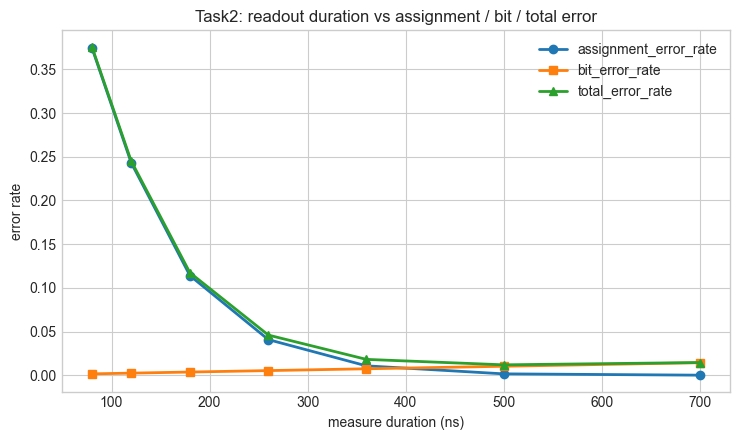

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(df['measure_duration_ns'], df['assignment_error_rate'], marker='o', linewidth=2, label='assignment_error_rate')
ax.plot(df['measure_duration_ns'], df['bit_error_rate'], marker='s', linewidth=2, label='bit_error_rate')
ax.plot(df['measure_duration_ns'], df['total_error_rate'], marker='^', linewidth=2, label='total_error_rate')
ax.set_xlabel('measure duration (ns)')
ax.set_ylabel('error rate')
ax.set_title('Task2: readout duration vs assignment / bit / total error')
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
best_duration_ns = float(df.loc[df['total_error_rate'].idxmin(), 'measure_duration_ns'])
example = results_by_duration[best_duration_ns]

pd.DataFrame(
    [
        {'metric': 'best_duration_ns', 'value': best_duration_ns},
        {'metric': 'assignment_error_rate', 'value': example['assignment_error_rate']},
        {'metric': 'bit_error_rate', 'value': example['bit_error_rate']},
        {'metric': 'total_error_rate', 'value': example['total_error_rate']},
        {'metric': 'centroid_separation', 'value': example['centroid_separation']},
    ]
)


,metric,value
0,best_duration_ns,500.000000
1,assignment_error_rate,0.001667
2,bit_error_rate,0.010343
3,total_error_rate,0.011993
4,centroid_separation,0.000160


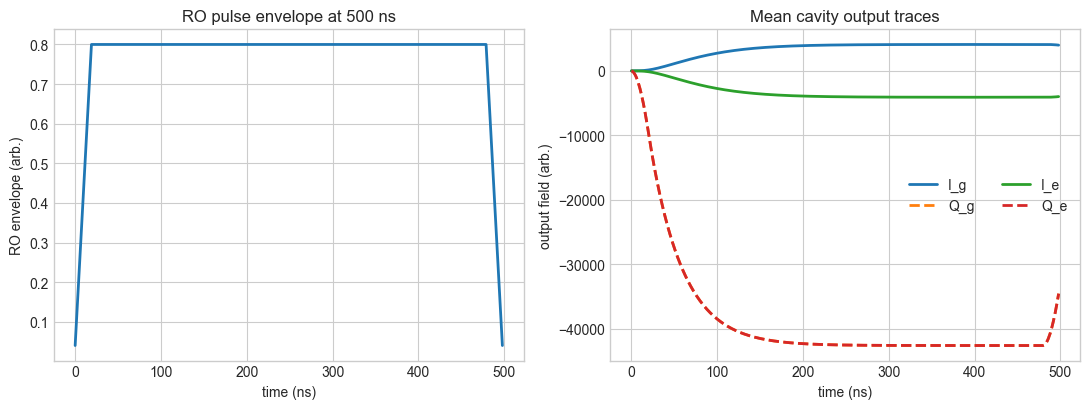

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

t_ns = 1.0e9 * example['t_s']
axes[0].plot(t_ns, example['envelope'], linewidth=2, color='tab:blue')
axes[0].set_xlabel('time (ns)')
axes[0].set_ylabel('RO envelope (arb.)')
axes[0].set_title(f'RO pulse envelope at {best_duration_ns:.0f} ns')

axes[1].plot(t_ns, example['output_g'].real, linewidth=2, label='I_g')
axes[1].plot(t_ns, example['output_g'].imag, linewidth=2, linestyle='--', label='Q_g')
axes[1].plot(t_ns, example['output_e'].real, linewidth=2, label='I_e')
axes[1].plot(t_ns, example['output_e'].imag, linewidth=2, linestyle='--', label='Q_e')
axes[1].set_xlabel('time (ns)')
axes[1].set_ylabel('output field (arb.)')
axes[1].set_title('Mean cavity output traces')
axes[1].legend(ncols=2)

plt.tight_layout()
plt.show()


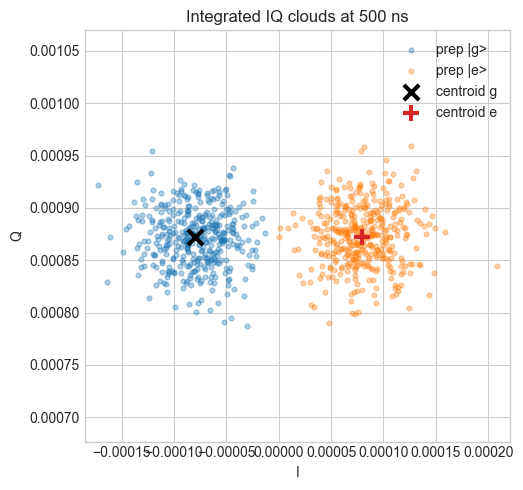

In [12]:
fig, ax = plt.subplots(figsize=(5.3, 5.0))
ax.scatter(example['z_g'][:IQ_PLOT_SHOTS].real, example['z_g'][:IQ_PLOT_SHOTS].imag, s=12, alpha=0.35, label='prep |g>')
ax.scatter(example['z_e'][:IQ_PLOT_SHOTS].real, example['z_e'][:IQ_PLOT_SHOTS].imag, s=12, alpha=0.35, label='prep |e>')
ax.scatter([example['centroid_g'].real], [example['centroid_g'].imag], s=120, marker='x', linewidth=3, color='black', label='centroid g')
ax.scatter([example['centroid_e'].real], [example['centroid_e'].imag], s=120, marker='+', linewidth=3, color='tab:red', label='centroid e')
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.set_title(f'Integrated IQ clouds at {best_duration_ns:.0f} ns')
ax.legend(loc='best')
ax.axis('equal')
plt.tight_layout()
plt.show()


## How To Retune Parameters

If you want to turn task2 into a different readout-chain study, the main knobs are:

- `templates/pulses/single_qubit_readout.json`
  - `measure_duration_ns`
  - `readout_edge_ns`
  - `ro_freq_Hz`
- `templates/devices/single_qubit_readout.json`
  - `cavity_freq_Hz`
  - `g_cavity_Hz`
  - `T1_s` / `Tup_s`
- notebook constant `READOUT_CHAIN_DEFAULTS`
  - `kappa_Hz`
  - `kappa_ext_Hz`
  - `drive_scale_Hz`
  - `line_noise_sigma`

If you want the horizontal axis to become readout-line noise strength instead of readout-pulse duration, keep `measure_duration_ns` fixed and sweep `READOUT_CHAIN_DEFAULTS['line_noise_sigma']` in the notebook.
